In [42]:
%load_ext autoreload
%autoreload 2
%aimport sleep_stager

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [57]:
from sleep_stager.load import find_psg_hypnogram_pairs

SC_DIR = "../data/sleep-cassette"
ST_DIR = "../data/sleep-telemetry"

sc_pairs = find_psg_hypnogram_pairs(SC_DIR)
st_pairs = find_psg_hypnogram_pairs(ST_DIR)

SFREQ = 100.0

print(len(sc_pairs))
print(len(st_pairs))

# TODO why only 153 and 44?


[WindowsPath('../data/sleep-cassette/SC4001E0-PSG.edf'), WindowsPath('../data/sleep-cassette/SC4002E0-PSG.edf'), WindowsPath('../data/sleep-cassette/SC4011E0-PSG.edf'), WindowsPath('../data/sleep-cassette/SC4012E0-PSG.edf'), WindowsPath('../data/sleep-cassette/SC4021E0-PSG.edf'), WindowsPath('../data/sleep-cassette/SC4022E0-PSG.edf'), WindowsPath('../data/sleep-cassette/SC4031E0-PSG.edf'), WindowsPath('../data/sleep-cassette/SC4032E0-PSG.edf'), WindowsPath('../data/sleep-cassette/SC4041E0-PSG.edf'), WindowsPath('../data/sleep-cassette/SC4042E0-PSG.edf'), WindowsPath('../data/sleep-cassette/SC4051E0-PSG.edf'), WindowsPath('../data/sleep-cassette/SC4052E0-PSG.edf'), WindowsPath('../data/sleep-cassette/SC4061E0-PSG.edf'), WindowsPath('../data/sleep-cassette/SC4062E0-PSG.edf'), WindowsPath('../data/sleep-cassette/SC4071E0-PSG.edf'), WindowsPath('../data/sleep-cassette/SC4072E0-PSG.edf'), WindowsPath('../data/sleep-cassette/SC4081E0-PSG.edf'), WindowsPath('../data/sleep-cassette/SC4082E0-PS

# Bandpass filtering

In [54]:
from sleep_stager.load import load_subject

X_raw, y_raw, available_channels = load_subject(sc_pairs[0][0], sc_pairs[0][1], do_bandpass=False)

X, y, _ = load_subject(sc_pairs[0][0], sc_pairs[0][1], do_bandpass=True)



Available channels in SC4001E0-PSG.edf: ['EEG Fpz-Cz', 'EEG Pz-Oz', 'EOG horizontal', 'EMG submental']


<string>:30: RuntimeWarning: Limited 1 annotation(s) that were expanding outside the data range.


Available channels in SC4001E0-PSG.edf: ['EEG Fpz-Cz', 'EEG Pz-Oz', 'EOG horizontal', 'EMG submental']


<string>:30: RuntimeWarning: Limited 1 annotation(s) that were expanding outside the data range.


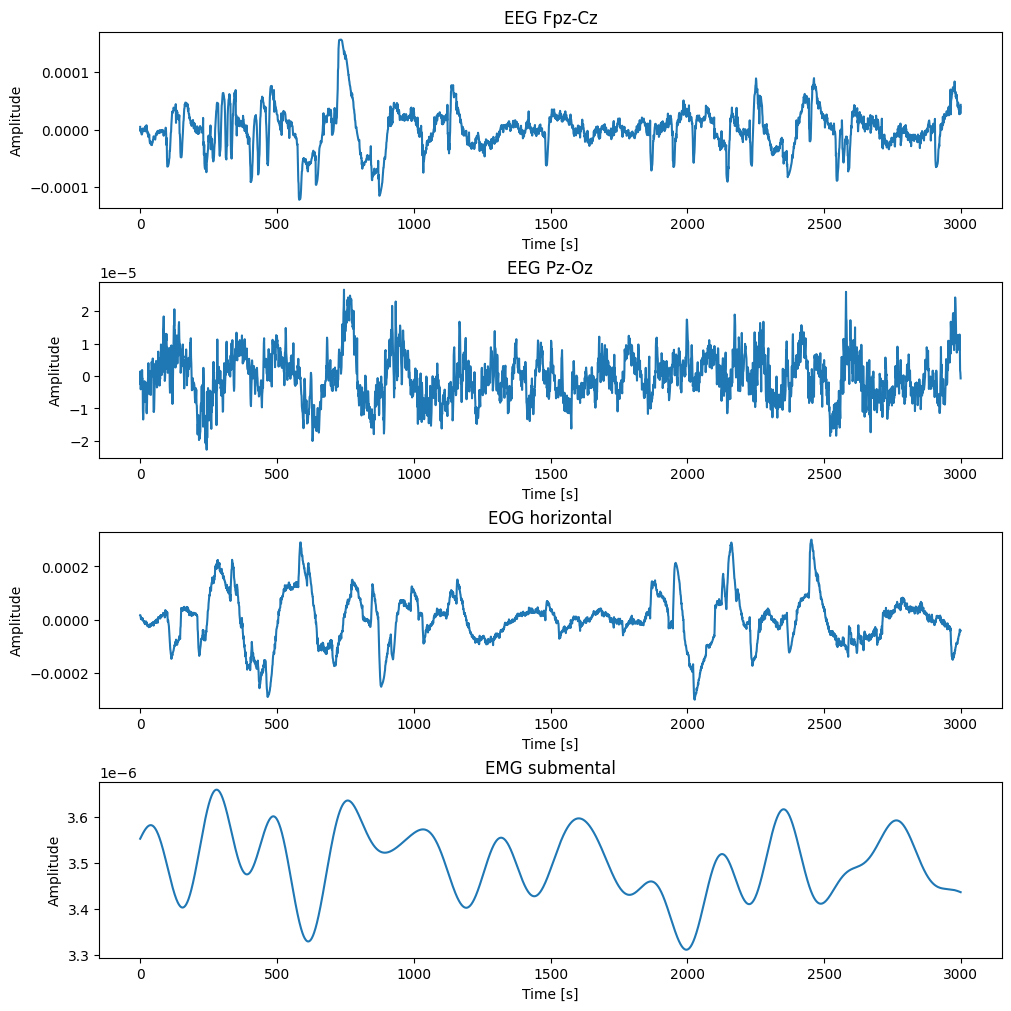

In [63]:
# plot random epochs
import matplotlib.pyplot as plt
import numpy as np


fig, axes = plt.subplots(len(available_channels), 1, figsize=(10, 10), constrained_layout=True)

epoch_idx = 500
n_samples = X_raw.shape[2]
time = np.arange(n_samples) / SFREQ

for i, ch in enumerate(available_channels):
    axes[i].plot(X_raw[0, i, :])
    axes[i].set_title(ch)
    axes[i].set_xlabel("Time [s]")
    axes[i].set_ylabel("Amplitude")


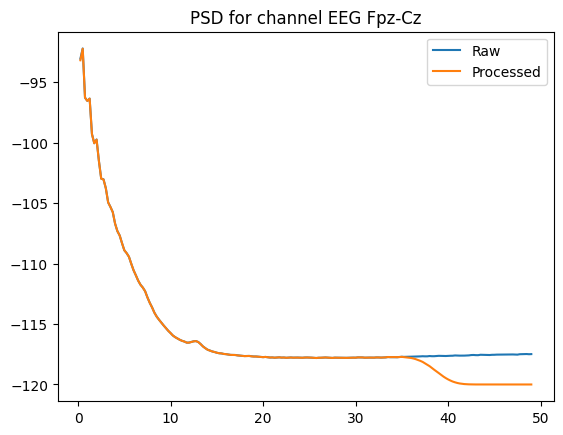

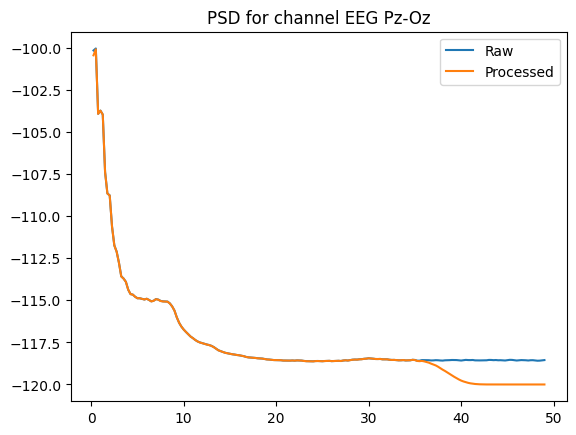

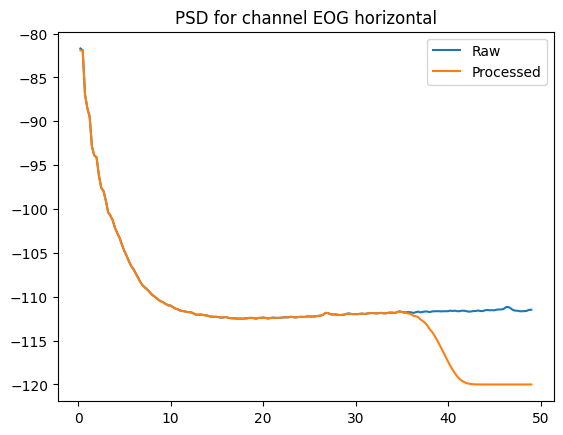

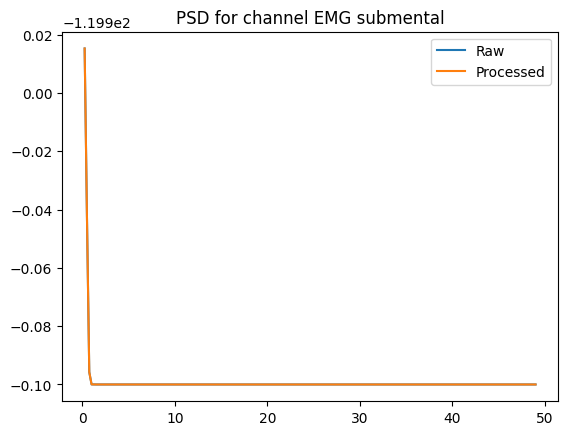

In [67]:
import numpy as np
import matplotlib.pyplot as plt
from sleep_stager.load import compute_welch_psd
sfreq = 100.0  # Hz
psds_raw, freqs = compute_welch_psd(
    X_raw,
    sfreq=sfreq,
    fmin=0.1,
    fmax=49.0,
    nperseg=int(4 * sfreq),
    noverlap=int(2 * sfreq),
)

psds_filt, freqs = compute_welch_psd(
    X,
    sfreq=sfreq,
    fmin=0.1,
    fmax=49.0,
    nperseg=int(4 * sfreq),
    noverlap=int(2 * sfreq),
)

mean_raw = psds_raw.mean(axis=0)
mean_filt = psds_filt.mean(axis=0)
mean_raw_db = 10 * np.log10(mean_raw + 1e-12)
mean_filt_db = 10 * np.log10(mean_filt + 1e-12)

for psd_raw, psd, ch in zip(mean_raw_db, mean_filt_db, available_channels):
    plt.plot(freqs, psd_raw, label="Raw")
    plt.plot(freqs, psd, label="Processed")
    plt.title(f"PSD for channel {ch}")
    #
    #plt.yscale("log")
    #plt.xscale("log")
    plt.legend()
    plt.show()

